In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display

In [2]:
df = spoti.load_all_tracks(data_path.DATA_PATH, users_list.USERS, load_spotify_tracks=True)
df

,album,artists,available_markets,disc_number,duration_ms,episode,explicit,external_ids,external_urls,href,...,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,time_range,affinity,release_year,normalized_genres
0,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,251488,False,False,{'isrc': 'GBF088590110'},{'spotify': 'https://open.spotify.com/track/4R...,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,...,audio_features,spotify:track:4RvWPyQ5RL0ao9LPZeSouE,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,https://api.spotify.com/v1/audio-analysis/4RvW...,251489,4,NaN,NaN,NaN,NaN
1,"{'album_type': 'compilation', 'artists': [{'ex...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,256146,False,False,{'isrc': 'GBF088590112'},{'spotify': 'https://open.spotify.com/track/74...,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,...,audio_features,spotify:track:748yv6bb3l3CcKS45a6SZ8,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,https://api.spotify.com/v1/audio-analysis/748y...,256147,4,NaN,NaN,NaN,NaN
2,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,209106,False,False,{'isrc': 'GBUM71103440'},{'spotify': 'https://open.spotify.com/track/7n...,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,...,audio_features,spotify:track:7nhWtCc3v6Vem80gYPlppQ,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,https://api.spotify.com/v1/audio-analysis/7nhW...,209107,4,NaN,NaN,NaN,NaN
3,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,170786,False,False,{'isrc': 'GBUM71029609'},{'spotify': 'https://open.spotify.com/track/4v...,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,...,audio_features,spotify:track:4vhVDkSx9RSb2k6mWFMYNI,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,https://api.spotify.com/v1/audio-analysis/4vhV...,170787,4,NaN,NaN,NaN,NaN
4,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,264253,False,False,{'isrc': 'GBUM71029621'},{'spotify': 'https://open.spotify.com/track/5R...,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,...,audio_features,spotify:track:5RYLa5P4qweEAKq5U1gdcK,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,https://api.spotify.com/v1/audio-analysis/5RYL...,264253,4,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20061,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,211213,False,True,{'isrc': 'IT4U11700019'},{'spotify': 'https://open.spotify.com/track/07...,https://api.spotify.com/v1/tracks/07VhWcjtxG9f...,...,audio_features,spotify:track:07VhWcjtxG9fe1jZixSY3F,https://api.spotify.com/v1/tracks/07VhWcjtxG9f...,https://api.spotify.com/v1/audio-analysis/07Vh...,211213,4,NaN,NaN,2017.0,"[rap, pop, indie]"
20062,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,162864,False,False,{'isrc': 'USAT21904486'},{'spotify': 'https://open.spotify.com/track/6r...,https://api.spotify.com/v1/tracks/6rVNnvyNeibt...,...,audio_features,spotify:track:6rVNnvyNeibts1uOqdSNIw,https://api.spotify.com/v1/tracks/6rVNnvyNeibt...,https://api.spotify.com/v1/audio-analysis/6rVN...,162864,3,NaN,NaN,2019.0,"[pop, pop]"
20063,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,143791,False,True,{'isrc': 'USAT21903333'},{'spotify': 'https://open.spotify.com/tr

In [3]:
px.pie(df, names="username", title="Number of Liked Tracks per User")

In [4]:
df_count_genres = preprocessing.count_list_column_per_user(df, "genres", normalize=True)
px.bar(df_count_genres, x="username", y="count", color="genres", title="Number of Liked Tracks per Genre")

In [5]:
df_count_genres = preprocessing.count_list_column_per_user(df, "normalized_genres", normalize=True)
px.bar(df_count_genres, x="username", y="count", color="normalized_genres", title="Number of Liked Tracks per Genre")

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_68950/223927714.py:1: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



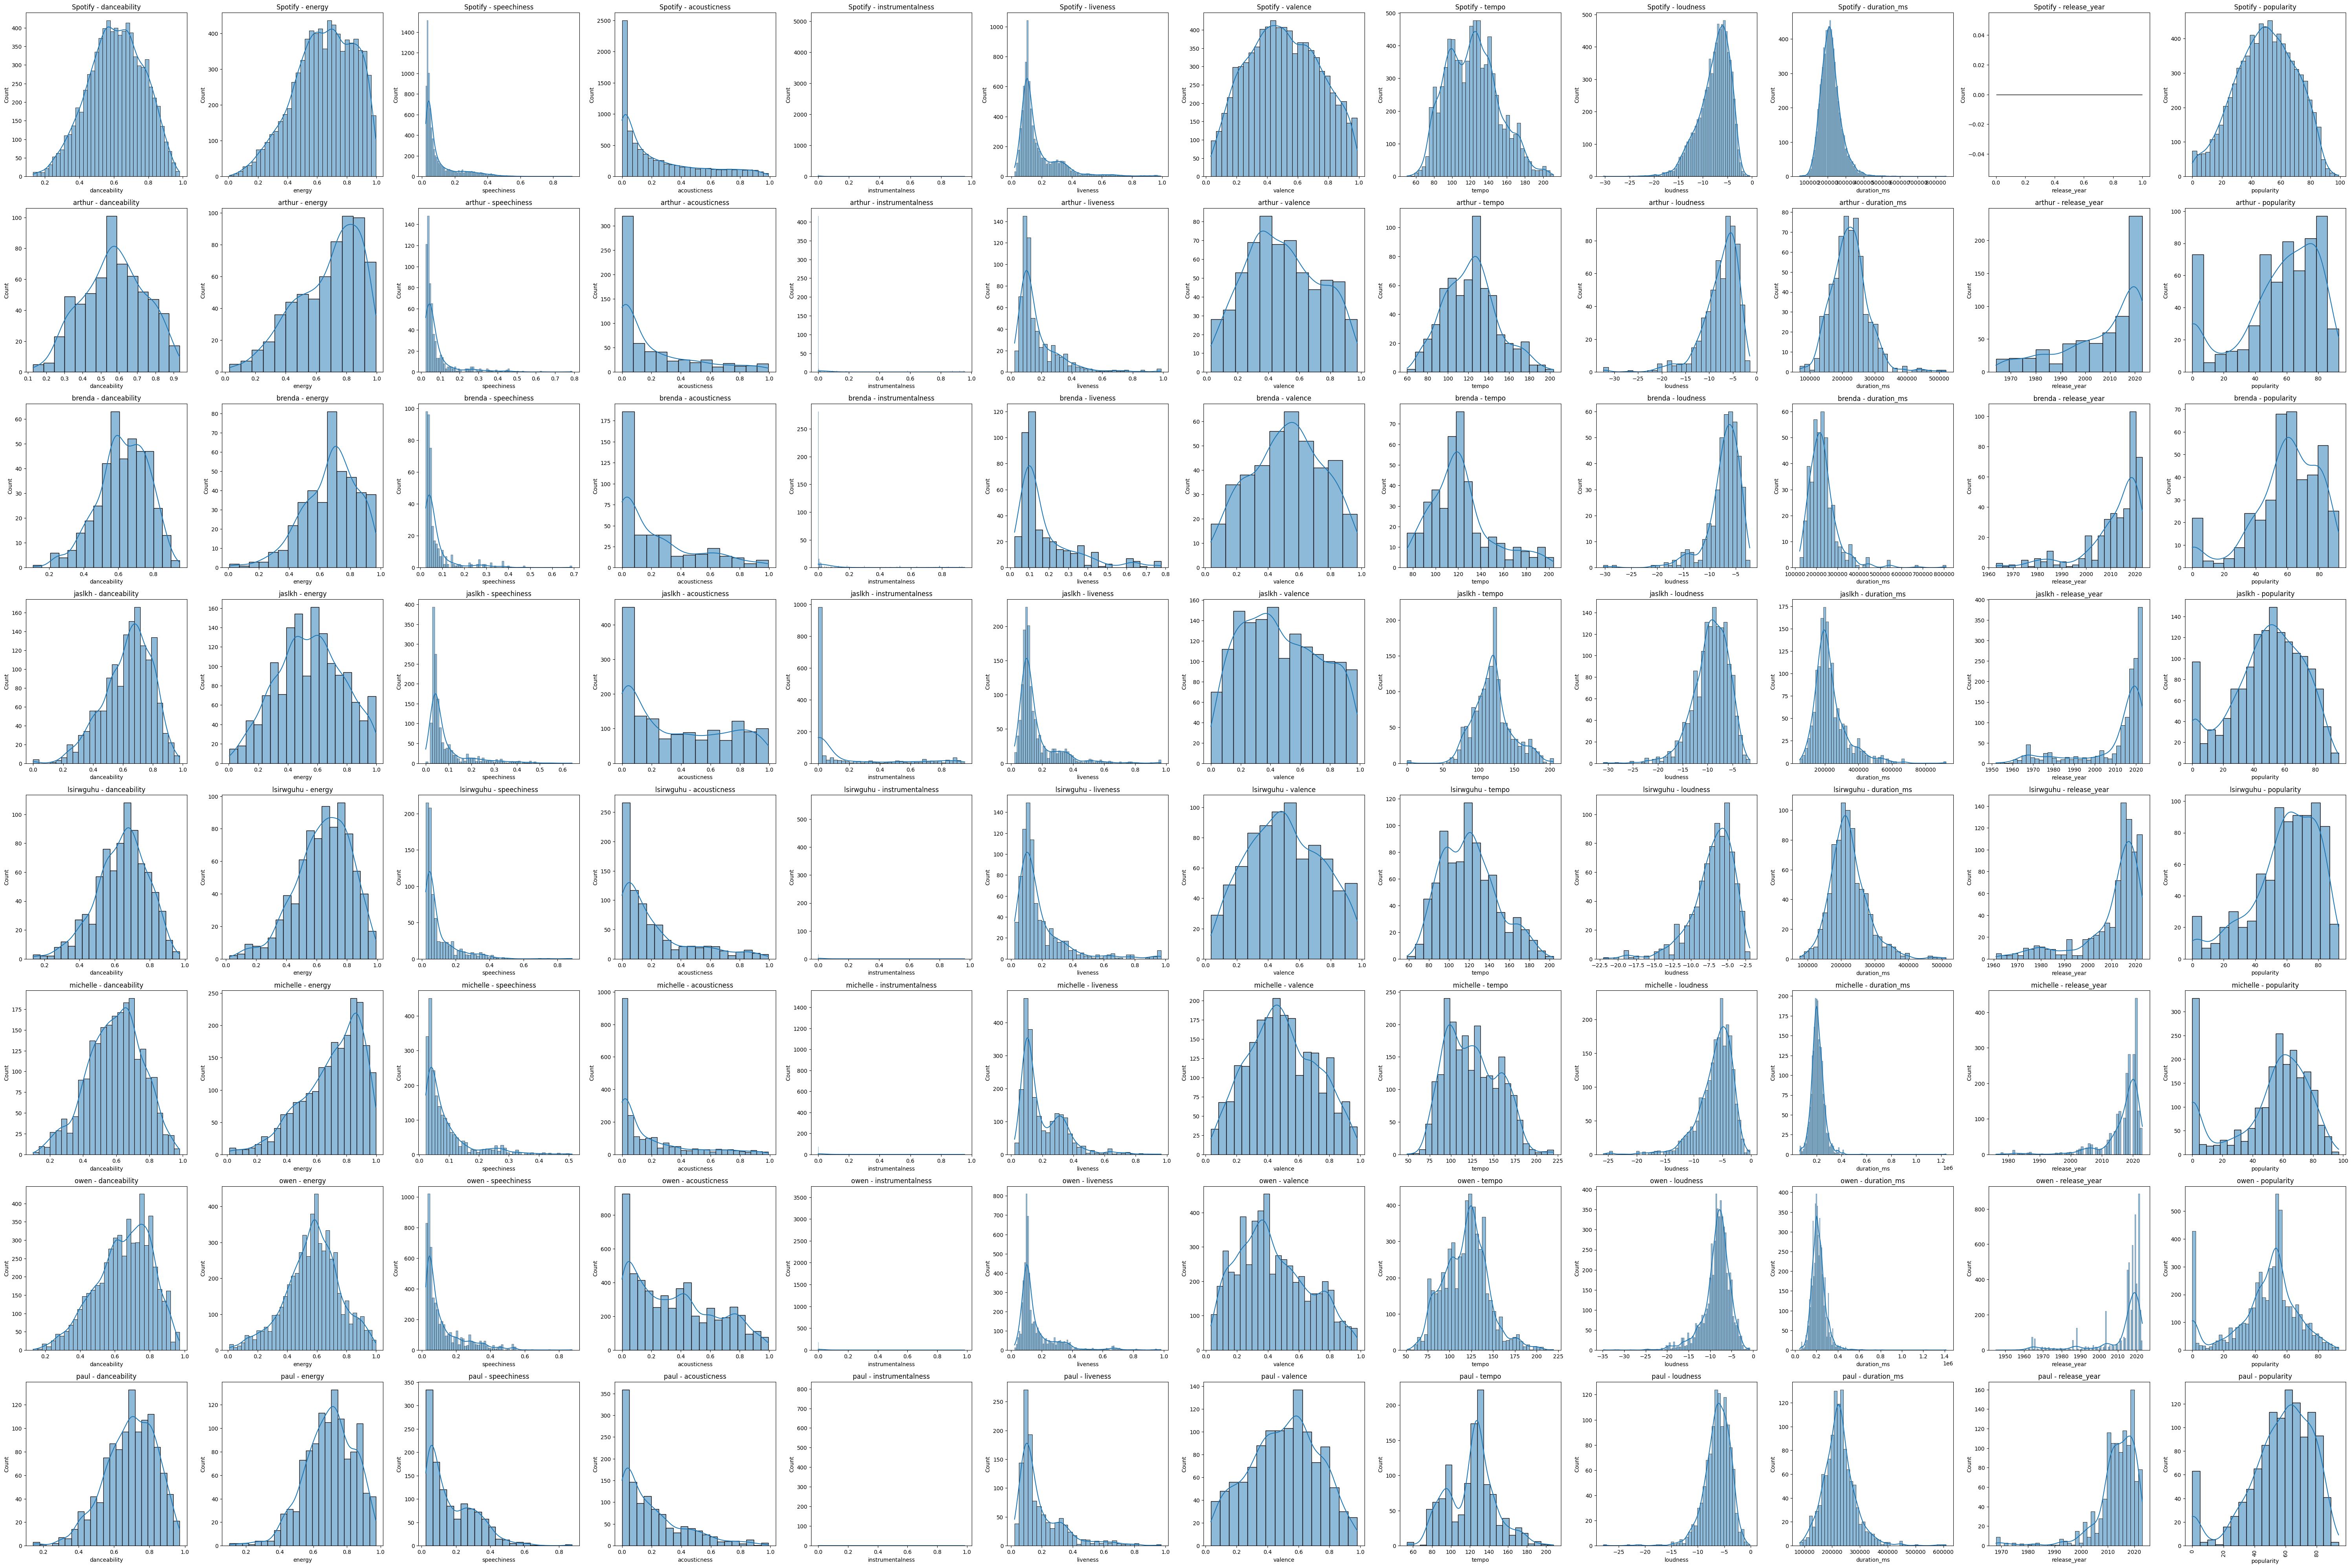

In [6]:
plotting.plot_column_distributions(df.groupby("username")).show()